In [1]:
!pip install datasets transformers manga109api Pillow torch torchvision ultralytics

from google.colab import userdata
from datasets import load_dataset
import zipfile
import manga109api
import os

from ultralytics import YOLO
from PIL import Image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
from huggingface_hub import login
login(token=userdata.get('HF_TOKEN'))

In [3]:
from huggingface_hub import login
from google.colab import userdata

# Re-attempt login after adding the secret
token = userdata.get('HF_TOKEN')
if token:
    login(token=token)
    print("Successfully attempted Hugging Face login. Check the output above for confirmation.")
else:
    print("HF_TOKEN secret not found. Please ensure it's set in Colab's Secrets tab.")

Successfully attempted Hugging Face login. Check the output above for confirmation.


In [4]:
from huggingface_hub import login, snapshot_download
import os

# Force token into the environment explicitly
token = userdata.get('HF_TOKEN')
login(token=token, add_to_git_credential=False)

# Also set it as env var as a fallback
os.environ["HF_TOKEN"] = token

path = snapshot_download(
    repo_id="hal-utokyo/Manga109",
    repo_type="dataset",
    local_dir="/content/manga109",
    token=token   # ← pass it explicitly here
)
print(path)

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

/content/manga109


In [5]:
for root, dirs, files in os.walk("/content/manga109"):
    level = root.replace("/content/manga109", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # only show files for top 2 levels
        for f in files[:5]:  # limit to 5 files per folder
            print(f"{indent}  {f}")

manga109/
  Manga109_released_2023_12_07.zip
  README.md
  .gitattributes
  .cache/
    huggingface/
      download/


In [6]:
zip_path = "/content/manga109/Manga109_released_2023_12_07.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    print(z.namelist()[:20])  # preview contents first

['Manga109_released_2023_12_07/', '__MACOSX/._Manga109_released_2023_12_07', 'Manga109_released_2023_12_07/books.txt', '__MACOSX/Manga109_released_2023_12_07/._books.txt', 'Manga109_released_2023_12_07/annotations.v2020.12.18/', '__MACOSX/Manga109_released_2023_12_07/._annotations.v2020.12.18', 'Manga109_released_2023_12_07/images/', '__MACOSX/Manga109_released_2023_12_07/._images', 'Manga109_released_2023_12_07/annotations.v2018.05.31/', '__MACOSX/Manga109_released_2023_12_07/._annotations.v2018.05.31', 'Manga109_released_2023_12_07/annotations/', '__MACOSX/Manga109_released_2023_12_07/._annotations', 'Manga109_released_2023_12_07/readme.txt', '__MACOSX/Manga109_released_2023_12_07/._readme.txt', 'Manga109_released_2023_12_07/annotations_COO/', '__MACOSX/Manga109_released_2023_12_07/._annotations_COO', 'Manga109_released_2023_12_07/annotations_Manga109Dialog/', '__MACOSX/Manga109_released_2023_12_07/._annotations_Manga109Dialog', 'Manga109_released_2023_12_07/annotations.v2020.12.18/M

In [7]:
extract_path = "/content/manga109_data"

with zipfile.ZipFile(zip_path, 'r') as z:
    members = [m for m in z.namelist() if not m.startswith("__MACOSX")]
    z.extractall(extract_path, members=members)

print("Done!")

Done!


In [8]:
data_root = "/content/manga109_data/Manga109_released_2023_12_07"
api = manga109api.Parser(root_dir=data_root)

# List all books
print(api.books)

['ARMS', 'AisazuNihaIrarenai', 'AkkeraKanjinchou', 'Akuhamu', 'AosugiruHaru', 'AppareKappore', 'Arisa', 'BEMADER_P', 'BakuretsuKungFuGirl', 'Belmondo', 'BokuHaSitatakaKun', 'BurariTessenTorimonocho', 'ByebyeC-BOY', 'Count3DeKimeteAgeru', 'DollGun', 'Donburakokko', 'DualJustice', 'EienNoWith', 'EvaLady', 'EverydayOsakanaChan', 'GOOD_KISS_Ver2', 'GakuenNoise', 'GarakutayaManta', 'GinNoChimera', 'Hamlet', 'HanzaiKousyouninMinegishiEitarou', 'HaruichibanNoFukukoro', 'HarukaRefrain', 'HealingPlanet', 'HeiseiJimen', 'HighschoolKimengumi_vol01', 'HighschoolKimengumi_vol20', 'HinagikuKenzan', 'HisokaReturns', 'JangiriPonpon', 'JijiBabaFight', 'Joouari', 'Jyovolley', 'KarappoHighschool', 'KimiHaBokuNoTaiyouDa', 'KoukouNoHitotachi', 'KuroidoGanka', 'KyokugenCyclone', 'LancelotFullThrottle', 'LoveHina_vol01', 'LoveHina_vol14', 'MAD_STONE', 'MadouTaiga', 'MagicStarGakuin', 'MagicianLoad', 'MariaSamaNihaNaisyo', 'MayaNoAkaiKutsu', 'MemorySeijin', 'MeteoSanStrikeDesu', 'MiraiSan', 'MisutenaideDaisy'


image 1/1 /content/manga109_data/Manga109_released_2023_12_07/images/ARMS/001.jpg: 480x640 (no detections), 67.5ms
Speed: 14.3ms preprocess, 67.5ms inference, 7.8ms postprocess per image at shape (1, 3, 480, 640)


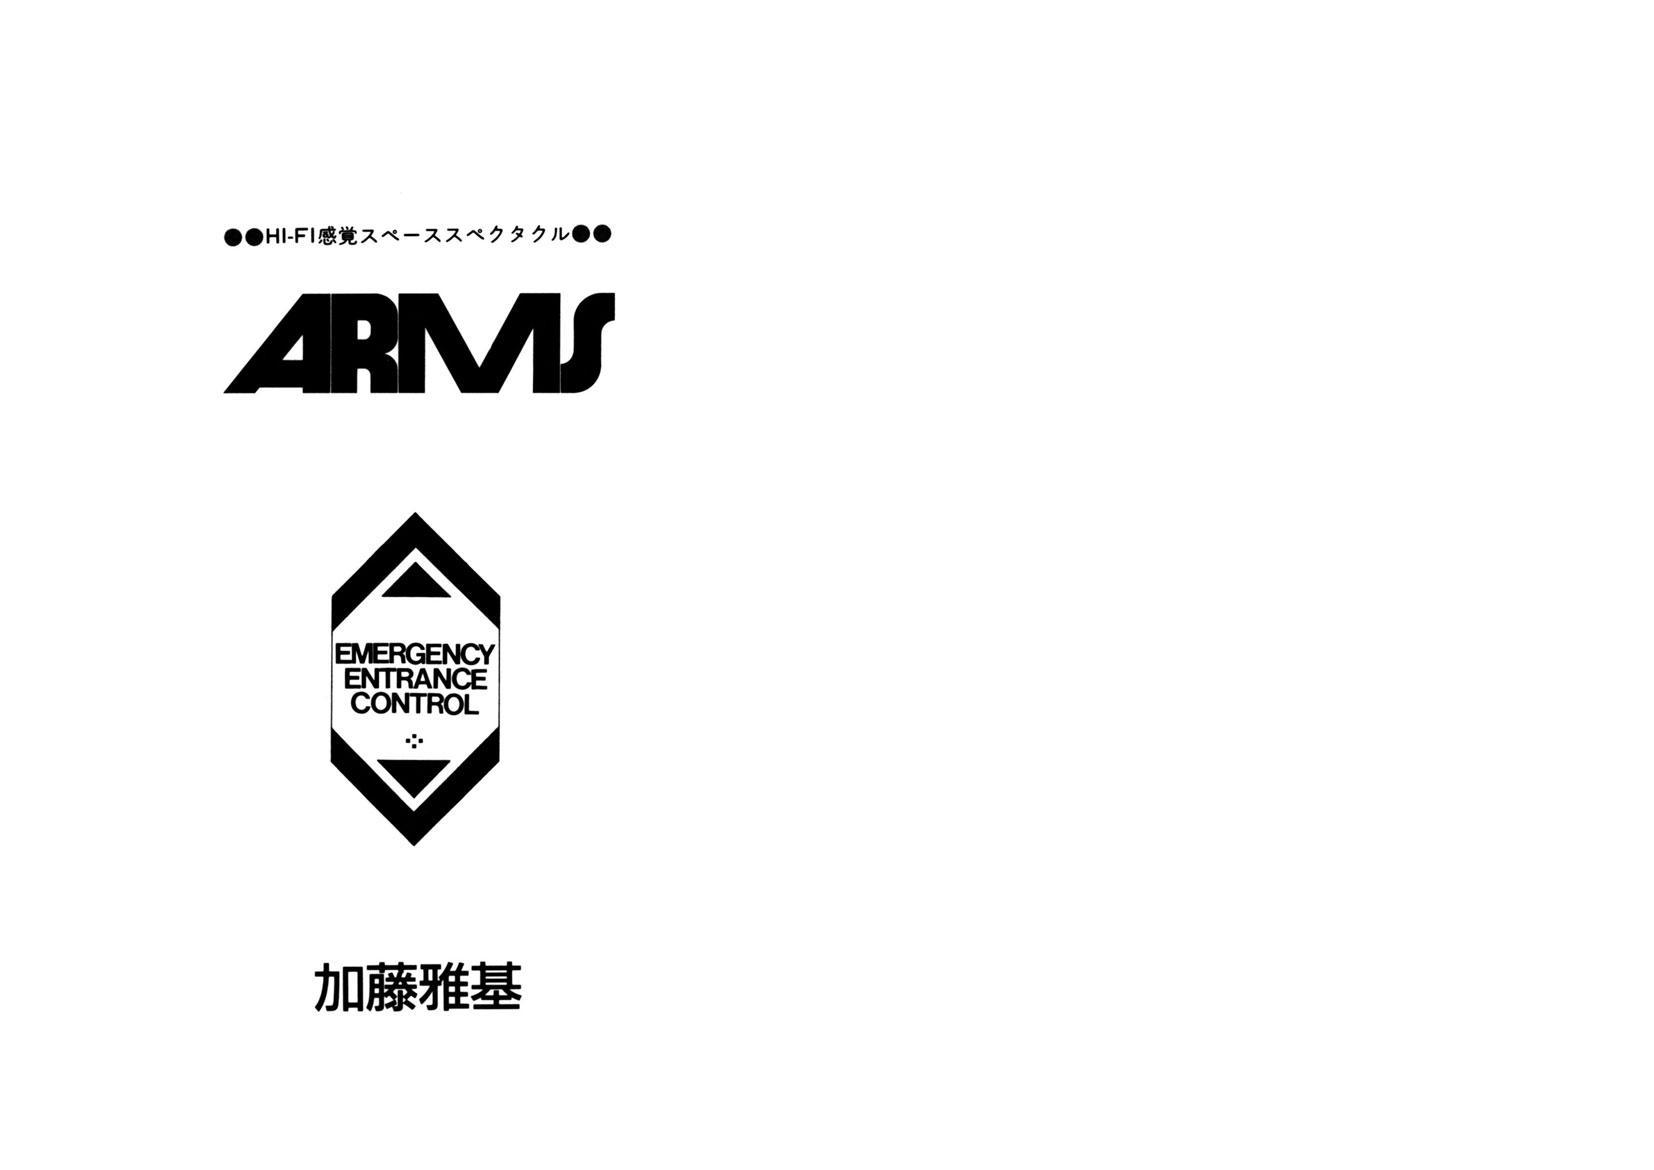

In [9]:
# Load pretrained YOLOv26 model
model = YOLO("yolo26n.pt")  # will auto-download

# Test on first page
data_root = "/content/manga109_data/Manga109_released_2023_12_07"

import manga109api
api = manga109api.Parser(root_dir=data_root)
book = api.books[0]

img_path = os.path.join(data_root, "images", book, "001.jpg")
results = model(img_path)
results[0].show()

In [10]:
import os
from PIL import Image

LABEL2ID = {"body": 0, "text": 1}

def convert_all_annotations(api, data_root, label_out_root):
    image_dir = os.path.join(data_root, "images")

    for book in api.books:
        ann = api.get_annotation(book=book)

        for page in ann['page']:
            page_index = page['@index']
            W = page['@width']
            H = page['@height']

            img_filename = f"{page_index:03d}.jpg"
            img_path = os.path.join(image_dir, book, img_filename)
            if not os.path.exists(img_path):
                continue

            lines = []
            for tag, label_id in LABEL2ID.items():
                for item in page[tag]:
                    x1 = item['@xmin']
                    y1 = item['@ymin']
                    x2 = item['@xmax']
                    y2 = item['@ymax']

                    cx = ((x1 + x2) / 2) / W
                    cy = ((y1 + y2) / 2) / H
                    w  = (x2 - x1) / W
                    h  = (y2 - y1) / H
                    lines.append(f"{label_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

            label_out = os.path.join(label_out_root, book)
            os.makedirs(label_out, exist_ok=True)
            with open(os.path.join(label_out, img_filename.replace(".jpg", ".txt")), "w") as f:
                f.write("\n".join(lines))

    print("Annotation conversion done!")

label_out_root = "/content/manga109_labels"
convert_all_annotations(api, data_root, label_out_root)

Annotation conversion done!


In [11]:
# Verify a label file looks right
import random
book = random.choice(api.books)
label_file = f"/content/manga109_labels/{book}/002.txt"
if os.path.exists(label_file):
    with open(label_file) as f:
        print(f.read())

In [12]:
import shutil, yaml, os

data_root = "/content/manga109_data/Manga109_released_2023_12_07"
image_dir = os.path.join(data_root, "images")
label_out_root = "/content/manga109_labels"
dataset_root = "/content/manga109_dataset"

# Train/val split (80/20)
all_books = api.books
split = int(len(all_books) * 0.8)
train_books = all_books[:split]
val_books = all_books[split:]

print(f"Train: {len(train_books)} books, Val: {len(val_books)} books")

# Copy images and labels into dataset folder
for split_name, books in [("train", train_books), ("val", val_books)]:
    img_split_dir = os.path.join(dataset_root, "images", split_name)
    lbl_split_dir = os.path.join(dataset_root, "labels", split_name)
    os.makedirs(img_split_dir, exist_ok=True)
    os.makedirs(lbl_split_dir, exist_ok=True)

    for book in books:
        src_img = os.path.join(image_dir, book)
        src_lbl = os.path.join(label_out_root, book)
        dst_img = os.path.join(img_split_dir, book)
        dst_lbl = os.path.join(lbl_split_dir, book)

        if os.path.exists(src_img) and not os.path.exists(dst_img):
            shutil.copytree(src_img, dst_img)
        if os.path.exists(src_lbl) and not os.path.exists(dst_lbl):
            shutil.copytree(src_lbl, dst_lbl)

print("Dataset split done!")

Train: 87 books, Val: 22 books
Dataset split done!


In [13]:
# Write the YAML config
cfg = {
    "path": dataset_root,
    "train": "images/train",
    "val": "images/val",
    "nc": 2,
    "names": {0: "body", 1: "text"}
}

yaml_path = os.path.join(dataset_root, "manga109.yaml")
with open(yaml_path, "w") as f:
    yaml.dump(cfg, f)

print("YAML written!")

YAML written!


In [14]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

model.train(
    data=yaml_path,
    epochs=20,
    imgsz=640,
    batch=8,
    name="manga109_yolo26n",
    project="/content/runs",
    device=0  # GPU
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/manga109_dataset/manga109.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=manga109_yolo26n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c386953d7c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [15]:
metrics = model.val()
print(f"mAP50:    {metrics.box.map50:.3f}")
print(f"mAP50-95: {metrics.box.map:.3f}")

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2037.9±380.2 MB/s, size: 373.1 KB)
val: Scanning /content/manga109_dataset/labels/val/TapkunNoTanteisitsu.cache... 2077 images, 94 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2077/2077 335.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 130/130 3.2it/s 41.2s
                   all       2077      59398      0.874      0.811       0.89      0.635
                  body       1979      31178      0.851      0.743      0.852      0.586
                  text       1962      28220      0.898       0.88      0.929      0.683
Speed: 1.5ms preprocess, 4.3ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val
mAP50:    0.890
mAP50-95: 0.635


In [16]:
import time
import torch
import numpy as np
from ultralytics import YOLO

model = YOLO("/content/runs/manga109_yolo26n/weights/best.pt")

# ── 1. Standard val metrics ──────────────────────────────────────────────────
metrics = model.val(data=yaml_path, imgsz=640, batch=8)

map50    = metrics.box.map50
map5095  = metrics.box.map
map50_per_class  = metrics.box.ap50       # per-class AP50
map5095_per_class = metrics.box.ap        # per-class AP50-95
precision = metrics.box.mp               # mean precision
recall    = metrics.box.mr               # mean recall

print(f"mAP50:          {map50:.4f}")
print(f"mAP50-95:       {map5095:.4f}")
print(f"Mean Precision: {precision:.4f}")
print(f"Mean Recall:    {recall:.4f}")
print(f"AP50  per class (body, text): {map50_per_class}")
print(f"AP50-95 per class (body, text): {map5095_per_class}")

# ── 2. F1 score ───────────────────────────────────────────────────────────────
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
print(f"F1 Score:       {f1:.4f}")

# ── 3. Inference speed ────────────────────────────────────────────────────────
import os
from PIL import Image

# Grab a sample image
sample_book = api.books[0]
sample_img = os.path.join(data_root, "images", sample_book, "002.jpg")

# Warmup
for _ in range(3):
    model(sample_img, verbose=False)

# Timed runs
times = []
for _ in range(50):
    start = time.perf_counter()
    model(sample_img, verbose=False)
    times.append((time.perf_counter() - start) * 1000)  # ms

avg_ms  = np.mean(times)
std_ms  = np.std(times)
fps     = 1000 / avg_ms
print(f"\nInference speed (50 runs):")
print(f"  Avg latency: {avg_ms:.2f} ms ± {std_ms:.2f} ms")
print(f"  FPS:         {fps:.1f}")

# ── 4. Model size & params ────────────────────────────────────────────────────
weights_path = "/content/runs/manga109_yolo26n/weights/best.pt"
model_size_mb = os.path.getsize(weights_path) / (1024 ** 2)
param_count   = sum(p.numel() for p in model.model.parameters())

print(f"\nModel size:   {model_size_mb:.2f} MB")
print(f"Param count:  {param_count / 1e6:.2f} M")

# ── 5. Summary dict (easy to compare across models later) ────────────────────
results = {
    "model":          "YOLO26n",
    "mAP50":          round(map50, 4),
    "mAP50-95":       round(map5095, 4),
    "precision":      round(precision, 4),
    "recall":         round(recall, 4),
    "f1":             round(f1, 4),
    "AP50_body":      round(map50_per_class[0], 4),
    "AP50_text":      round(map50_per_class[1], 4),
    "AP5095_body":    round(map5095_per_class[0], 4),
    "AP5095_text":    round(map5095_per_class[1], 4),
    "latency_ms":     round(avg_ms, 2),
    "fps":            round(fps, 1),
    "model_size_mb":  round(model_size_mb, 2),
    "params_M":       round(param_count / 1e6, 2),
}

print("\n── Summary ──")
for k, v in results.items():
    print(f"  {k}: {v}")

# Save to JSON so you can load and compare later
import json
with open("/content/results_yolo26n.json", "w") as f:
    json.dump(results, f, indent=2)
print("\nSaved to /content/results_yolo26n.json")

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2781.6±663.2 MB/s, size: 398.9 KB)
val: Scanning /content/manga109_dataset/labels/val/TapkunNoTanteisitsu.cache... 2077 images, 94 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2077/2077 580.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 260/260 6.5it/s 40.2s
                   all       2077      59398      0.874      0.811       0.89      0.635
                  body       1979      31178      0.851      0.743      0.852      0.586
                  text       1962      28220      0.898       0.88      0.929      0.683
Speed: 1.4ms preprocess, 5.3ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val-2
mAP50:          0.8904
mAP50-95:       0.6345
Mean Precision: 

In [18]:
from google.colab import drive
drive.mount('/drive')

import shutil
shutil.copytree(
    "/content/runs/manga109_yolo26n",
    "/drive/MyDrive/CV-Comic-Project/manga109_yolo26n",
    dirs_exist_ok=True
)
print("Saved to Drive!")

Mounted at /drive
Saved to Drive!
